<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

# Machine learning: Analysing the data set
----
*Georg Kaufmann,
Geophysics Section,
Institute of Geological Sciences,
Freie Universität Berlin,
Germany*

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import csv

### Load data set

Note: we need to change the flower names to numbers ...

In [57]:
X = np.zeros([150*4]).reshape(150,4)
y = np.zeros([150])
print(X.ndim,X.shape)

csvfile = open('data/iris.csv', newline='')
iris = csv.reader(csvfile, delimiter=',')
next(iris)
i=0
for row in iris:
    X[i,0] = row[0]
    X[i,1] = row[1]
    X[i,2] = row[2]
    X[i,3] = row[3]
    if (row[4]=='Iris-setosa'):
        y[i] = 0
    elif (row[4]=='Iris-versicolor'):
        y[i] = 1
    elif (row[4]=='Iris-virginica'):
        y[i] = 2
    i=i+1
print(X[0])
print(y[0])

2 (150, 4)
[5.1 3.5 1.4 0.2]
0.0


In [58]:
X_sepal_length = X[:, 0]
X_sepal_width =  X[:, 1]
X_petal_length = X[:, 2]
X_petal_width = X[:, 3]

### Split into training and test data set

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

In [60]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((90, 4), (90,), (60, 4), (60,))

### Fit with natural neighbors

In [61]:
from sklearn import neighbors

In [62]:
clf = neighbors.KNeighborsClassifier(1)

In [65]:
clf.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

In [66]:
clf.score(X_train,y_train)

1.0

In [67]:
clf.score(X_test,y_test)

0.95

In [68]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
font_size=25

def meshGrid(x_data, y_data):
    h = .02  # step size in the mesh
    x_min, x_max = x_data.min() - 1, x_data.max() + 1
    y_min, y_max = y_data.min() - 1, y_data.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return (xx,yy)
    
def plotPrediction(clf, x_data, y_data, x_label, y_label, colors, title="", mesh=True):
    xx,yy = meshGrid(x_data, y_data)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(20,10))
    if mesh:
        plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.scatter(x_data, y_data, c=colors, cmap=cmap_bold, s=80, marker='o')
    plt.xlabel(x_label, fontsize=font_size)
    plt.ylabel(y_label, fontsize=font_size)
    plt.title(title, fontsize=font_size)

Score fit train data:  0.9666666666666667
Score fit test data:   0.8


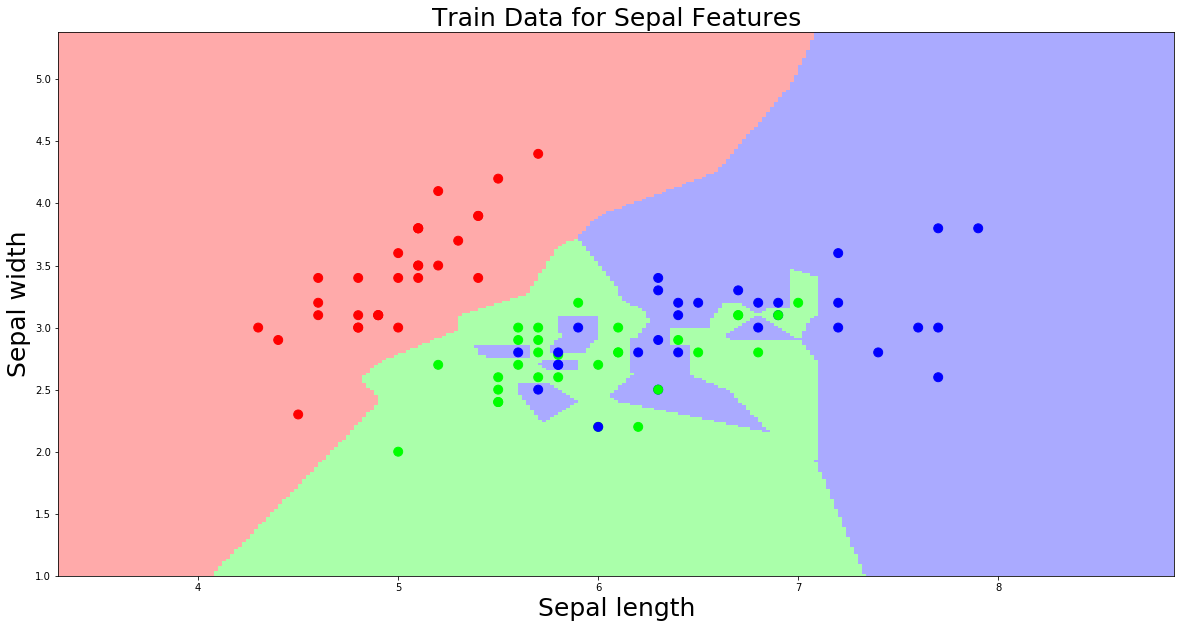

In [73]:
X_train_sepal_only = X_train[:, :2]
X_test_sepal_only = X_test[:, :2]
clf_sepal = neighbors.KNeighborsClassifier(1)
clf_sepal.fit(X_train_sepal_only, y_train)
print('Score fit train data: ',clf_sepal.score(X_train_sepal_only, y_train))
print('Score fit test data:  ',clf_sepal.score(X_test_sepal_only, y_test))
plotPrediction(clf_sepal, X_train_sepal_only[:, 0], X_train_sepal_only[:, 1], 
               'Sepal length', 'Sepal width', y_train, mesh=True,
                title="Train Data for Sepal Features")

Score fit train data:  0.8
Score fit test data:   0.7666666666666667


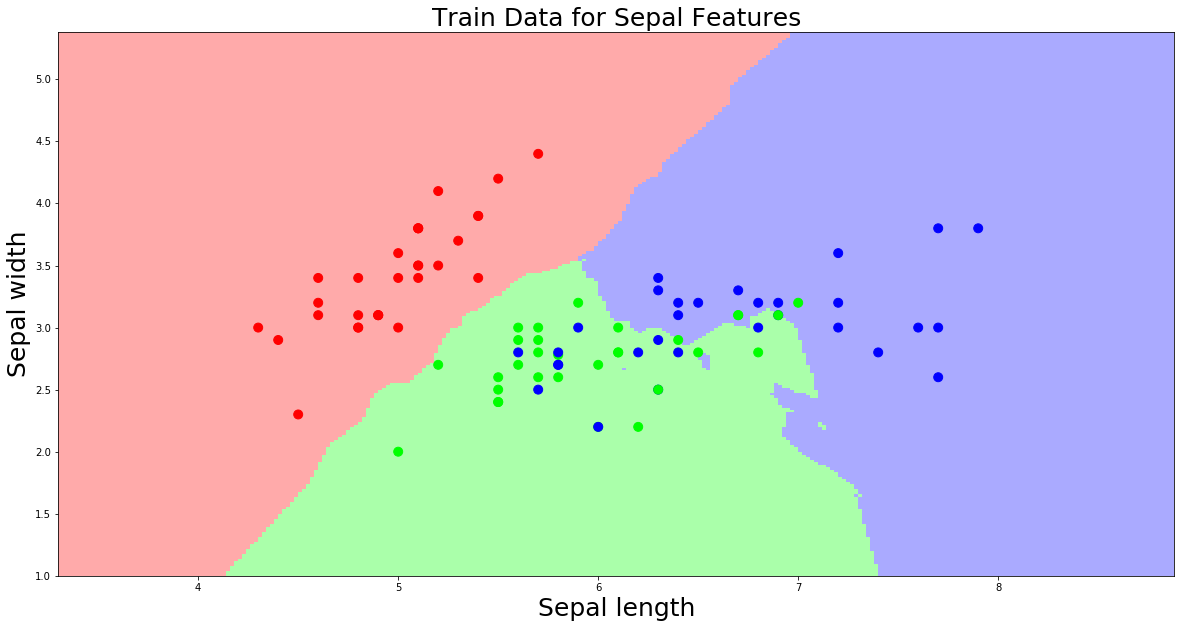

In [74]:
X_train_sepal_only = X_train[:, :2]
X_test_sepal_only = X_test[:, :2]
clf_sepal = neighbors.KNeighborsClassifier(10)
clf_sepal.fit(X_train_sepal_only, y_train)
print('Score fit train data: ',clf_sepal.score(X_train_sepal_only, y_train))
print('Score fit test data:  ',clf_sepal.score(X_test_sepal_only, y_test))
plotPrediction(clf_sepal, X_train_sepal_only[:, 0], X_train_sepal_only[:, 1], 
               'Sepal length', 'Sepal width', y_train, mesh=True,
                title="Train Data for Sepal Features")

Score fit train data:  0.9666666666666667
Score fit test data:   0.95


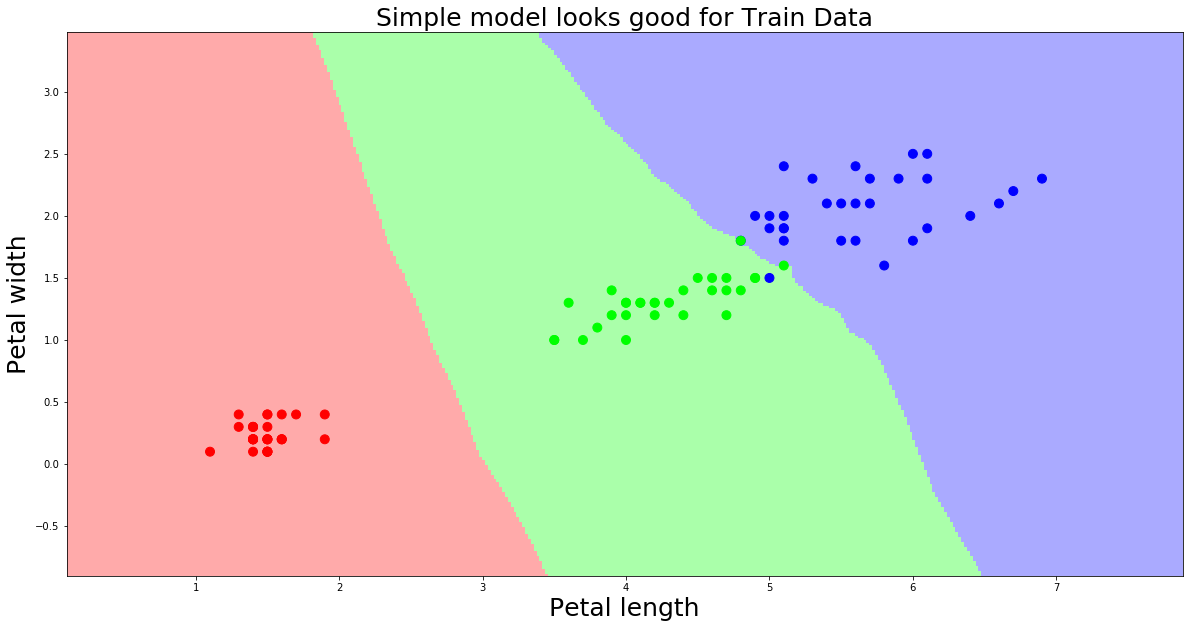

In [77]:
X_train_petal_only = X_train[:, 2:]
X_test_petal_only = X_test[:, 2:]
clf_petal = neighbors.KNeighborsClassifier(10)
clf_petal.fit(X_train_petal_only, y_train)
print('Score fit train data: ',clf_petal.score(X_train_petal_only, y_train))
print('Score fit test data:  ',clf_petal.score(X_test_petal_only, y_test))
plotPrediction(clf_petal, X_train_petal_only[:, 0], X_train_petal_only[:, 1], 
               'Petal length', 'Petal width', y_train,
               title="Simple model looks good for Train Data")

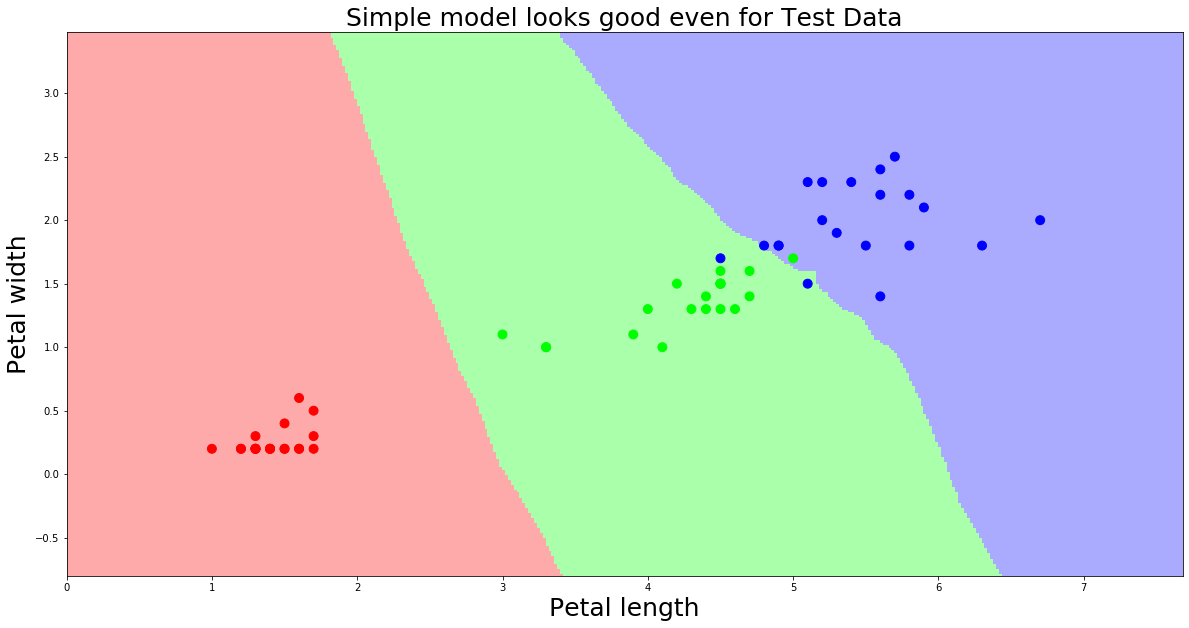

In [79]:
plotPrediction(clf_petal, X_test_petal_only[:, 0], X_test_petal_only[:, 1], 
               'Petal length', 'Petal width', y_test,
               title="Simple model looks good even for Test Data")

[next>](03_iris2.ipynb)